In [1]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count



import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# DQN: RL + Deep Neural Networks
Learns policy by approximating the Q-values with a Deep NN. Is sutiable for problems with high dimensional state spaces like image-based games.

In [2]:
# Create our training environment - a cart with a pole that needs balancing
env = gym.make("CartPole-v1", render_mode = 'rgb_array') # 'human' for a window screen
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display # to display the charts

plt.ion() # plt.ion() completely changes the behavior, making it an essential tool for live animations, like tracking your reinforcement learning agent's training progress in real-time.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # To check if a GPU is available

1. Replay Memory is a technique used in reinforcement learning to store and manage
the experiences of an agent during training. The idea is to store the agent's experiences
as a sequence of (state, action, reward, next_state) tuples, which are collected as the
agent interacts with the environment. During training, these experiences are used to
update the agent's policy and value function.

2. The Replay Memory allows the agent to learn from past experiences by randomly
sampling a batch of experiences from the memory buffer, rather than just learning from
the most recent experience. This helps to reduce the correlation between subsequent
experiences, which can improve the stability and convergence of the learning algorithm.
In addition, by storing experiences in a buffer, the agent can re-use past experiences to
update its policy and value function multiple times, which can further improve learning.

3. The Replay Memory is typically implemented as a fixed-size buffer or queue that
stores the most recent experiences. When the buffer is full, new experiences overwrite
the oldest experiences in the buffer. During training, a batch of experiences is randomly
sampled from the buffer and used to update the agent's policy and value function.
process is repeated iteratively until the agent converges to an optimal policy.

We'll be using experience replay memory for training our DQN. It stores the transition
that the agent observes, allowing us to reuse this data later. By sampling from it
randomly, the transitions that build up a batch are decorrelated. It has been shown that
this greatly stabilizes and improves the DQN training procedure.

For this, we're going to need two classses:

1. Transition - a named tuple representing a single transition in our environment. It
essentially maps (state, action) pairs to their (next_state, reward) result, with the state
being the screen difference image as described later on.

2. ReplayMemory - a cyclic buffer of bounded size that holds the transitions observed
recently. It also implements a .sample() method for selecting a random batch of
transitions for training.

# Transition
'namedtuple' is universally used to store Replay Buffers. It allows you to store millions of (state, action, reward, next_state)

In [ ]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

'''
In Python 3 (which we use today), 'class ReplayMemory(object):' this is completely implicit. Every class you write automatically inherits from object behind the scenes.

Writing class ReplayMemory: and class ReplayMemory(object): do the exact same thing now. If you see (object) in a script,
it just means the code was either written a few years ago or the programmer prefers explicit syntax!

self.memory: This sets up an instance variable that will hold all your agent's past experiences (the transitions of states, actions, and rewards).

deque([]): This instantiates an empty deque object. You can think of a deque as a specialized Python list designed for fast additions and removals from both ends.

maxlen=capacity: This is the magic parameter. It sets a strict, hard ceiling on how many items this container can hold (e.g., capacity=100000).


DEQUE
The Growth Phase: If your capacity is 10,000, and you add 5,000 experiences, it behaves exactly like a standard list. It just grows.

The Limit Hit: The exact moment you try to add item number 10,001, the deque doesn't throw an error or crash.
 Instead, it automatically deletes the oldest item at index 0 (the first experience you ever saved) to free up space, and appends the brand new experience to the very end.
'''

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity) # You can think of a deque as a specialized Python list designed for fast additions and removals from both ends.
    
    def push(self, *args):

        '''The *args syntax stands for "arbitrary arguments." 
        Adding an asterisk (*) before a parameter name tells Python: "I don't know exactly how many individual variables the user is going to pass into this function. 
        Take whatever they give you, pack it all together into a clean tuple, and hand it to me."'''

        self.memory.append(Transition(*args))
    
    def sample(self, batch_size): # randomly samples a batch of length batch_size. 
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)

# DQN Algorithm
DQN (Deep Q-Network) is a reinforcement learning algorithm that uses deep neura
networks to approximate the Q-function in a Q-learning algorithm.
The DQN algorithm in the context of the Cartpole environment can be summarized
following steps:

1. Initialize the Q-network with random weights

2. Sample an action using an epsilon-greedy policy, which selects the action with the
highest Q-value with probability 1-epsilon and a random action with probability epsilon.

3. Execute the action and observe the next state and reward.

4. Store the experience tuple (state, action, reward, next_state) in a replay buffer.

5. Sample a mini-batch of experiences from the replay buffer.

6. Compute the Q-target values for the mini-batch using the Bellman equation: Q_t = reward + gamma * max_a(Q(next_state, a)).

7. Compute the Q-values for the mini-batch using the current Q-network: Q_values
Q(state, action).

8. Compute the loss between the Q-values and the Q-target values and update the Q
network parameters using gradient descent.

9. Repeat steps 2-8 for a fixed number of episodes or until convergence.

The DQN algorithm uses a target network to stabilize the training process. The target
network is a copy of the Q-network that is updated less frequently than the Q-network
This helps to prevent the Q-values from oscillating during training.

In the Cartpole environment, the DQN algorithm learns to balance the pole on the cart by
moving the cart left or right. The Q-network takes the state of the environment as input
and outputs the Q-values for each possible action. The DQN algorithm learns to
maximize the Q-values by updating the Q-network parameters using gradient descent
With enough training, the DQN algorithm can learn to balance the pole on the cart for
extended periods of time.



Our model will be a convolutional neural network that takes in the difference between
the current and previous screen patches. It has two outputs, representing Q(s,left) and
Q(s,right) (where s is the input to the network). In effect, the network is trying to
predict the expected return of taking each action given the current input.

In [ ]:
class DQN(nn.Module):

    # Multi-Layer Perceptron with 3 layers
    # n_observations is our input(state of the environment) to the network
    # n_actions - number of possible actions in the environment
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128) # FCN
        self.layer2 = nn.Linear(128, 128) # FCN
        self.layer3 = nn.Linear(128, n_actions) 
    
    # Take input and pass it to the 3 layers of the NN.
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


# Training
During training, the Q-network is updated using the Bellman equation to minimize the
mean squared error between the predicted Q-values and the target Q-values. The target
Q-values are computed using the Q-network, but with the weights frozen and not
updated during the current iteration of training. This helps to stabilize the training
process and prevent the network from overfitting to the training data.

# Parameters 

```select_action``` - will select an action accordingly to an epsilon greedy policy. Simply
we'll sometimes use our model for choosing the action, and sometimes we'll just
sample one uniformly. The probability of choosing a random action will start at
```EPS_START``` and will decay exponentially towards ```EPS_END```. 

```EPS_DECAY``` controls the decay.

```plot_durations``` - a helper for plotting the durations of episodes, along with an average
over the last 100 episodes (the measure used in the official evaluations). The plot will be
underneath the cell containing the main training loop, and will update after every
episode.

In [5]:
BATCH_SIZE = 128 # number of transitions samples from the replay buffer
GAMMA = 0.99 # the discount factor
EPS_START = 0.9 # it is the starting value of epsilon
EPS_END = 0.05 # it is the final value of epsilon
EPS_DECAY = 1000 # Controls the rate of exponential decay of epsilon. Higher means slower decay
TAU = 0.005 # Update rate of the target network
LR = 1e-4 # Learning rate of AdamW optimizer

The main idea behind Adam is to combine the advantages of two other optimization techniques, AdaGrad and RMSProp.

In the DQN algorithm, we use the Adam optimizer to update the weights of our network
network based on the gradients of the loss function with respect to the parameter.
Specifically, we use the AdamW optimizer, which is a variant of Adam that also
incorporates weight decay regularization. Weight decay helps prevent overfitting by
adding a penalty to the loss function that is proportional to the magnitude of the
weights. By adding this penalty, the optimizer encourages the network to learn simpler
and more generalizable representations.


In summary, the AdamW optimizer is a widely used optimization algorithm in deep
learning, and it is used in the DQN algorithm to update the weights of the neural network
based on the gradients of the loss function with respect to the parameters, while also
incorporating weight decay regularization.

In [6]:
n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state) # prints 4 -> number of features in a single state

# 'target_net' is initialized with the same weight as 'policy_net'
policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr = LR, amsgrad=True) # optimizer for weights
memory = ReplayMemory(10000) # stores agent's experience - buffer size, which will be used for training
steps_done = 0 # keeps track of the number of steps taken by the agent

# INPUT - Current State and returns the action
def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = (EPS_END + (EPS_START - EPS_END)) * (math.exp(-1. * steps_done / EPS_DECAY))
    steps_done += 1

    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will retun the larget column value of each row
            # second column on the max results is the index of where the max element was found,
            # so we pich action with the largest expected reward
            return policy_net(state).max(1)[1].view(1,1) # GREEDY
    else:
        return torch.tensor([[env.action_space.sample()]], device = device , dtype=torch.long)

episode_durations = [] # keeps track of the duration of each episode

def plot_duration(show_result=False):
    if not show_result:
        return

    # Everything below here only runs ONCE at the very end of training
    plt.figure(figsize=(10, 5)) 
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    
    plt.title('Final Training Performance')
    plt.xlabel('Episode')
    plt.ylabel('Duration (Steps Survived)')
    
    # Plot the raw scores
    plt.plot(durations_t.numpy(), label='Raw Duration', alpha=0.6)

    # Compute and plot the 100-episode moving average trendline
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy(), label='100-Ep Moving Avg', linewidth=2)
    
    plt.legend()
    
    if is_ipython:
        display.clear_output(wait=True)
        display.display(plt.gcf())


# Training Loop

In [7]:
def optimize_model():
    # Check if we have enough samples for the Mini Batch
    if len(memory) < BATCH_SIZE:
        return
    # Extract a Mini Batch of transition(state, action, reward, next_state) from the replay memory

    transition = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transition)) # converts batch-array of Transitions to Transition of batch-array

    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool) # compute a mask of non-final states 
    # and concatenate the batch elements

    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1,action_batch.long()) # computing the Q-Value here
    next_state_values = torch.zeros(BATCH_SIZE, device = device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    
    # Calculate the Expected Q value for each transition using the Target Network

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # HUBER LOSS -> Less Sensitive to Outliers
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the Model -> BackPropogation
    optimizer.zero_grad()
    loss.backward()

    # In-Place gradient clipping
    # Clipped to prevent the exploding gradient problem, maximum value - 100
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

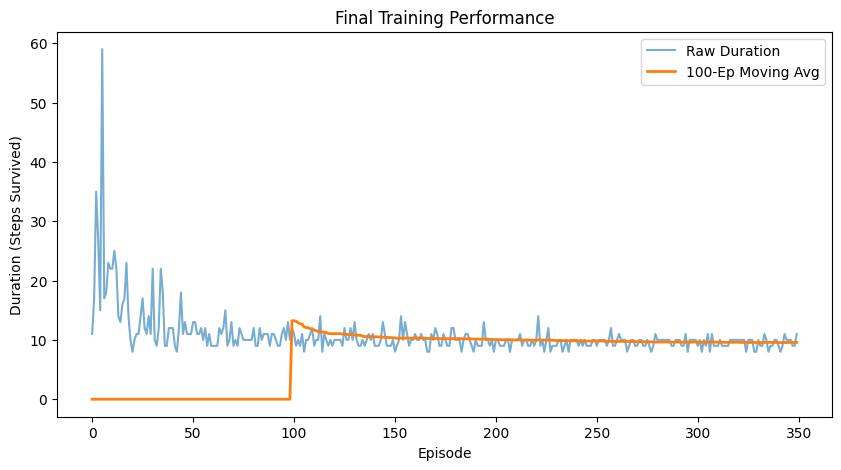

In [16]:
if torch.cuda.is_available():
    num_episodes = 600
else:
    num_episodes = 50

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    for t in count():
        action = select_action(state)
        observation, reward, truncated, terminated, info = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated 

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        
        memory.push(state, action, next_state, reward) # Store the transition in memory

        state  = next_state

        optimize_model()

        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()

        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_duration()
            break
print('Complete')
plot_duration(show_result=True)

